# Flow Matching: Root Finding

Find compressibility factors Z where the Peng-Robinson equation of state (PR-EOS) cubic equals zero.

Flow Matching learns a vector field that transforms a simple base distribution (e.g., Gaussian) to the target data distribution. For conditional generation, we condition the flow on desired output values.

**Problem:** Find roots of the PR-EOS cubic for propane at T=300 K, P=10 bar.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 11:09:03
Initial memory usage: 321.81 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Problem Setup

The Peng-Robinson equation of state in compressibility factor form is a cubic:

$$Z^3 - (1-B)Z^2 + (A-3B^2-2B)Z - (AB-B^2-B^3) = 0$$

In the two-phase region, this has three real roots: liquid ($Z_L$), unstable, and vapor ($Z_V$).

The approach:
1. Generate training data: pairs of $(Z, \text{residual}(Z))$
2. Train flow matching to generate $Z$ conditioned on residual
3. Sample by conditioning on residual $= 0$

Propane at T=300 K, P=10.0 bar
A = 0.183771, B = 0.022578

Analytical roots (Z values):
  Z_liquid   = 0.034783
  Z_unstable = 0.128036
  Z_vapor    = 0.814604


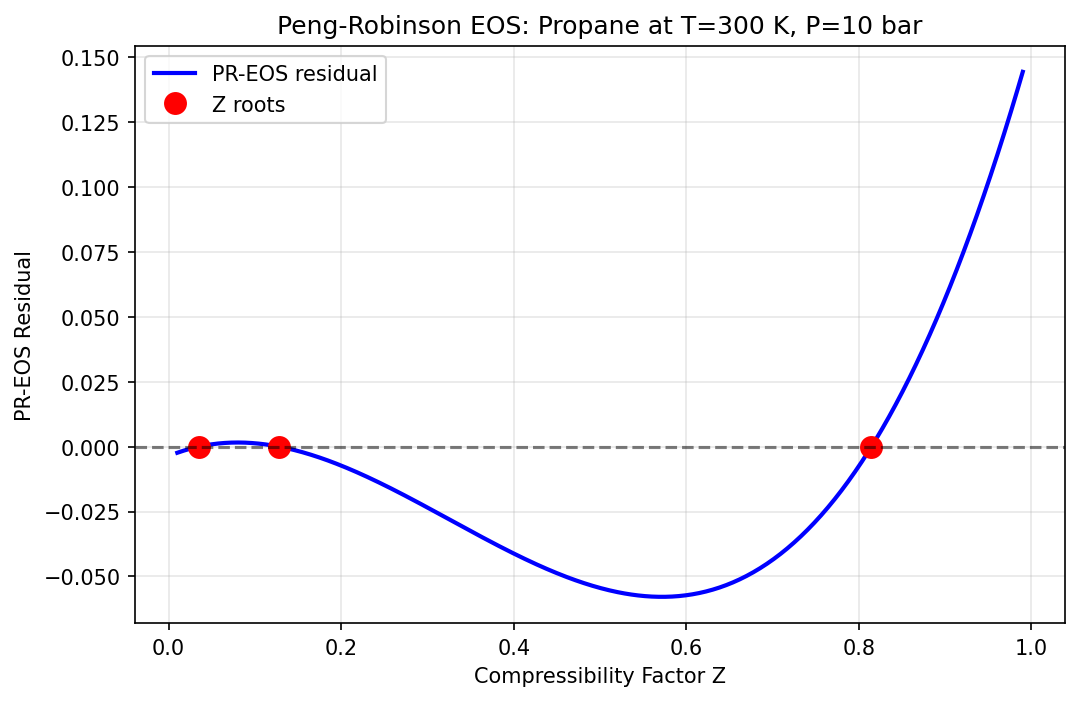

In [3]:
# Peng-Robinson EOS for propane
# Critical properties (NIST)
Tc = 369.83  # K - Critical temperature
Pc = 42.48e5  # Pa (42.48 bar) - Critical pressure
omega = 0.1523  # Acentric factor
R = 8.314  # J/(mol*K) - Gas constant

# PR-EOS parameters
kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2

def pr_eos_coefficients(T, P):
    """Calculate A, B and cubic coefficients for PR-EOS."""
    Tr = T / Tc
    alpha = (1 + kappa * (1 - np.sqrt(Tr)))**2
    a = 0.45724 * R**2 * Tc**2 / Pc * alpha
    b = 0.07780 * R * Tc / Pc
    A = a * P / (R**2 * T**2)
    B = b * P / (R * T)
    return A, B

def pr_eos_residual(Z, A, B):
    """Residual of PR-EOS cubic equation (should equal zero at roots)."""
    return Z**3 - (1-B)*Z**2 + (A - 3*B**2 - 2*B)*Z - (A*B - B**2 - B**3)

# Conditions: T=300 K, P=10 bar (two-phase region for propane)
T, P = 300, 10e5
A, B = pr_eos_coefficients(T, P)

# Analytical roots
coeffs = [1, -(1-B), (A - 3*B**2 - 2*B), -(A*B - B**2 - B**3)]
roots = np.roots(coeffs)
real_roots = np.sort(roots[np.abs(roots.imag) < 1e-10].real)

print(f"Propane at T={T} K, P={P/1e5:.1f} bar")
print(f"A = {A:.6f}, B = {B:.6f}")
print(f"\nAnalytical roots (Z values):")
print(f"  Z_liquid   = {real_roots[0]:.6f}")
print(f"  Z_unstable = {real_roots[1]:.6f}")
print(f"  Z_vapor    = {real_roots[2]:.6f}")

# Generate training data
Z_samples = np.linspace(0.01, 0.99, 500)
residual_samples = pr_eos_residual(Z_samples, A, B)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(Z_samples, residual_samples, 'b-', lw=2, label='PR-EOS residual')
plt.plot(real_roots, [0, 0, 0], 'ro', ms=10, label='Z roots')
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('Compressibility Factor Z')
plt.ylabel('PR-EOS Residual')
plt.legend()
plt.title(f'Peng-Robinson EOS: Propane at T={T} K, P={P/1e5:.0f} bar')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Prepare data for flow matching
# x_data: what we want to generate (compressibility factor Z)
# c_data: what we condition on (PR-EOS residual)

x_data = Z_samples.reshape(-1, 1)
c_data = residual_samples.reshape(-1, 1)

print(f"x_data shape: {x_data.shape}")
print(f"c_data shape: {c_data.shape}")

x_data shape: (500, 1)
c_data shape: (500, 1)


In [5]:
# Train flow matching model with larger architecture and more epochs
fm_root = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
losses = fm_root.fit(x_data, c_data, epochs=1000, batch_size=128, lr=1e-3)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

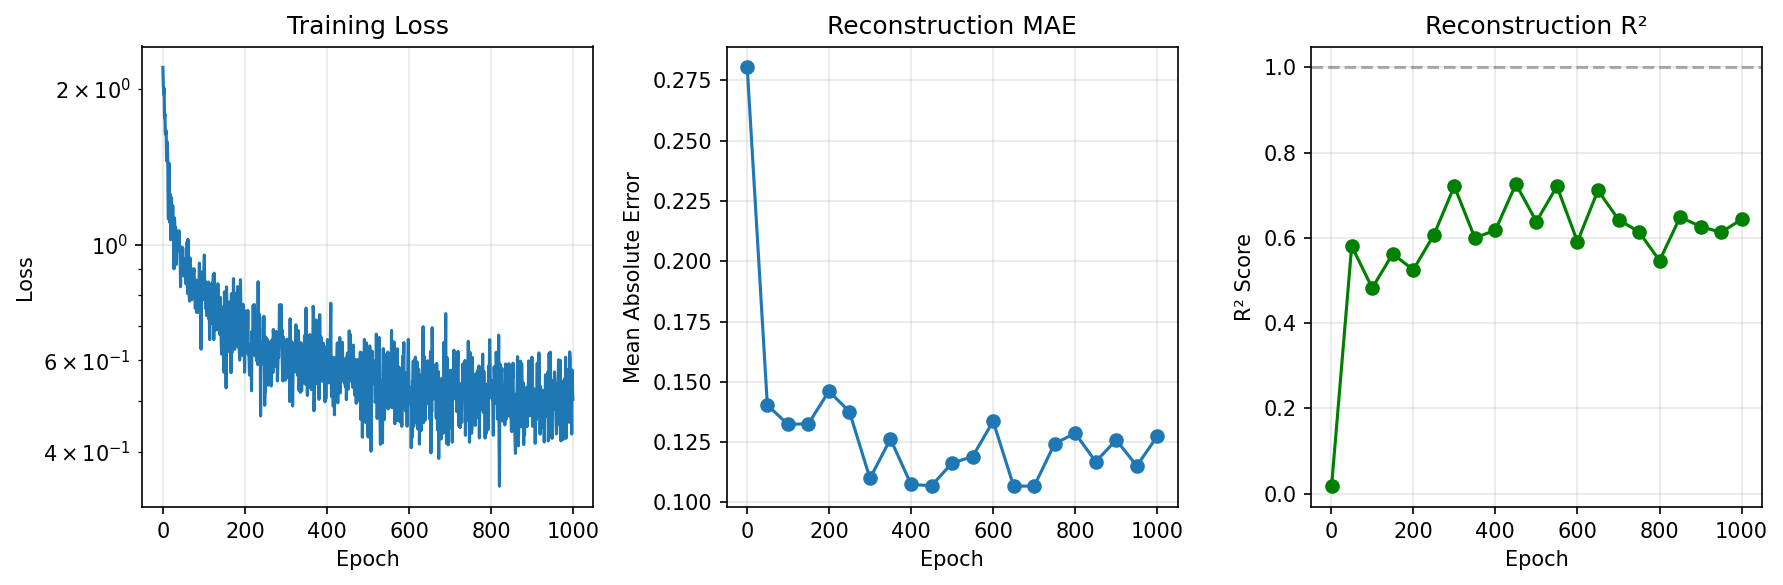

Final Loss: 0.505063
Final MAE:  0.127453
Final R²:   0.643718


In [6]:
# Plot learning curves (loss, MAE, R²)
fm_root.plot_learning_curves()

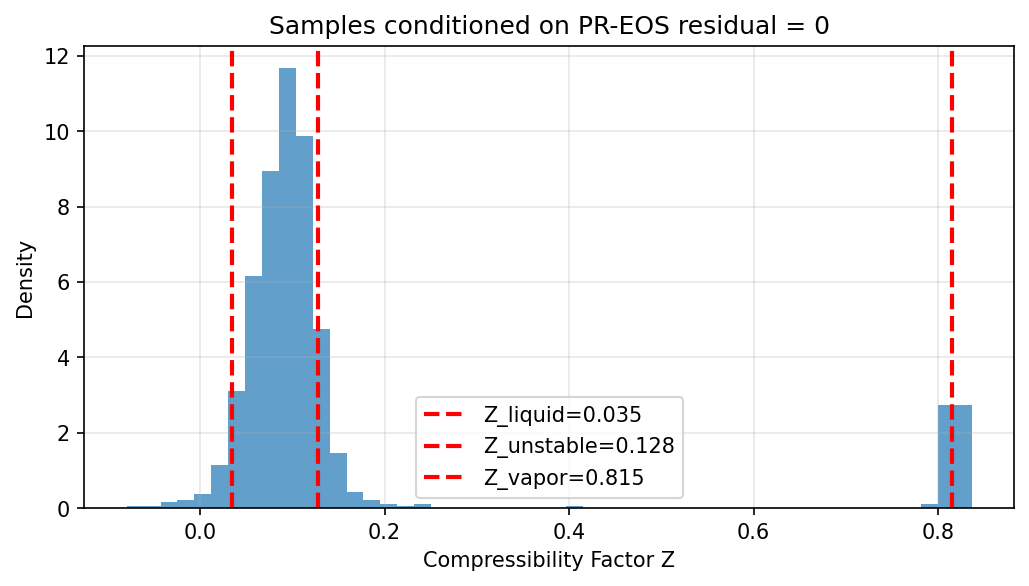


Cluster statistics (Z values):
 -1:   0.4000 +/- 0.0000 (n=1)
  0:   0.0903 +/- 0.0348 (n=897)
  1:   0.8190 +/- 0.0073 (n=102)

Analytical solutions:
  Z_liquid   = 0.0348
  Z_unstable = 0.1280
  Z_vapor    = 0.8146


In [7]:
# Sample roots by conditioning on residual=0
samples = fm_root.sample(c_values=[[0.0]], n_samples=1000, n_steps=100)

plt.figure(figsize=(8, 4))
plt.hist(samples[:, 0], bins=50, density=True, alpha=0.7)
for r in real_roots:
    plt.axvline(r, color='r', ls='--', lw=2)
plt.xlabel('Compressibility Factor Z')
plt.ylabel('Density')
plt.title('Samples conditioned on PR-EOS residual = 0')
plt.legend([f'Z_liquid={real_roots[0]:.3f}', f'Z_unstable={real_roots[1]:.3f}', f'Z_vapor={real_roots[2]:.3f}'])
plt.grid(True, alpha=0.3)
plt.show()

print("\nCluster statistics (Z values):")
cluster_stats(samples, eps=0.1)

print(f"\nAnalytical solutions:")
print(f"  Z_liquid   = {real_roots[0]:.4f}")
print(f"  Z_unstable = {real_roots[1]:.4f}")
print(f"  Z_vapor    = {real_roots[2]:.4f}")

In [8]:
# Verify the roots - check PR-EOS residual at sampled Z values
residual_at_samples = pr_eos_residual(samples[:, 0], A, B)
print("Verification: PR-EOS residual at sampled roots:")
print(f"  Mean |residual|: {np.mean(np.abs(residual_at_samples)):.6f}")
print(f"  Max |residual|:  {np.max(np.abs(residual_at_samples)):.6f}")

# Filter to valid roots
tol = 0.01
valid_roots_samples = samples[np.abs(residual_at_samples) < tol, 0]
print(f"\nAfter filtering (|residual| < {tol}): {len(valid_roots_samples)} samples")
print("Valid Z root clusters:")
cluster_stats(valid_roots_samples)

# Physical interpretation
print("\nPhysical interpretation:")
print("  Smallest Z: Liquid phase (dense, low compressibility)")
print("  Middle Z:   Unstable (spinodal region)")
print("  Largest Z:  Vapor phase (near ideal gas)")

Verification: PR-EOS residual at sampled roots:
  Mean |residual|: 0.001586
  Max |residual|:  0.041176

After filtering (|residual| < 0.01): 990 samples
Valid Z root clusters:
  0:   0.0904 +/- 0.0331 (n=892)
  1:   0.8184 +/- 0.0068 (n=98)

Physical interpretation:
  Smallest Z: Liquid phase (dense, low compressibility)
  Middle Z:   Unstable (spinodal region)
  Largest Z:  Vapor phase (near ideal gas)


In [9]:
# Can also condition on other residual values
# For example, find Z where the cubic equals a small non-zero value
samples_r001 = fm_root.sample(c_values=[[0.001]], n_samples=500)

print("Values of Z where PR-EOS cubic residual = 0.001:")
cluster_stats(samples_r001)

# Verify
residual_check = pr_eos_residual(samples_r001[:, 0], A, B)
print(f"\nMean residual at samples: {np.mean(residual_check):.6f} (expected: 0.001)")

Values of Z where PR-EOS cubic residual = 0.001:
  0:   0.1792 +/- 0.2523 (n=500)

Mean residual at samples: 0.000700 (expected: 0.001)


In [10]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 11:09:03
End time:        2025-12-18 11:09:14
Elapsed time:    10.80 seconds (0.18 minutes)
----------------------------------------------------------------------
Initial memory:  321.81 MB
Final memory:    472.77 MB
Memory change:   +150.95 MB
